# 02 — Preprocessing Pipeline (Forecasting Edition)
**PTB-XL ECG Dataset — Frankfurt University of Applied Sciences**

This notebook prepares the data for **time series forecasting** — not classification.
The key difference: instead of producing class labels as targets, we produce
**future signal windows** as regression targets.

```
Input  window: X_in   (N, INPUT_LEN=500, 12)  — 5 seconds of past ECG
Target window: y_fore (N, HORIZON=100,   12)  — 1 second of future ECG  ← regression target
```

Steps:
1. Load & alignment check
2. Missing value handling (linear interpolation)
3. Sampling rate consistency check
4. Z-score outlier clipping (±3σ)
5. Bandpass filter (0.5–40 Hz, Butterworth order 4)
6. Per-lead Z-score normalization
7. **[CHANGED] Forecasting window construction** — (X_in, y_fore) pairs
8. **[CHANGED] Forecasting sanity check** — visualise input → future target
9. Patient-wise train / val / test split (via PTB-XL strat_fold)
10. Training-time data augmentation (applied to X_in only, NOT y_fore)
11. **[CHANGED] Full sanity check** — verify shapes, value ranges, split integrity
12. Save all outputs to `data/processed/`

In [14]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt

warnings.filterwarnings('ignore')

SAVE_DIR   = os.path.join('..', 'data', 'processed')
FIG_DIR    = os.path.join('..', 'reports', 'figures')
FS         = 100       # sampling rate Hz
INPUT_LEN  = 500       # 5 seconds — encoder input
HORIZON    = 100       # 1 second  — forecast target
STRIDE     = 100       # step between windows
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

os.makedirs(FIG_DIR, exist_ok=True)

print("Imports OK ✅")
print(f"  Working dir  : {os.path.abspath('.')}")
print(f"  Processed dir: {os.path.abspath(SAVE_DIR)}")
print(f"  Forecast task: input={INPUT_LEN} samples ({INPUT_LEN/FS:.0f}s) → horizon={HORIZON} samples ({HORIZON/FS:.0f}s)")

Imports OK ✅
  Working dir  : /Users/muhammadfahadsiddiqui/HIS Project/notebooks
  Processed dir: /Users/muhammadfahadsiddiqui/HIS Project/data/processed
  Forecast task: input=500 samples (5s) → horizon=100 samples (1s)


### Step 1 — Load Data & Verify Alignment

In [15]:
# ============================================================
# CELL 2: LOAD RAW DATA & VERIFY ALIGNMENT
# ============================================================

X_raw    = np.load(os.path.join(SAVE_DIR, 'X_raw.npy'))          # (N, 1000, 12)
df       = pd.read_pickle(os.path.join(SAVE_DIR, 'metadata.pkl'))

batch_df = df.iloc[:len(X_raw)].copy()

assert len(X_raw) == len(batch_df), (
    f"Mismatch: X_raw={len(X_raw)} records but metadata={len(batch_df)} rows."
)

print("=" * 55)
print("  DATA LOAD & ALIGNMENT CHECK")
print("=" * 55)
print(f"  Waveforms     : {X_raw.shape}  → (records, samples, leads)")
print(f"  Metadata rows : {batch_df.shape}")
print(f"  Alignment     : ✅ OK — {len(X_raw)} records matched")
print(f"  Strat folds   : {sorted(batch_df['strat_fold'].unique())}")
print()
print("  NOTE: No class labels loaded — this is a FORECASTING pipeline.")
print("  Targets will be constructed as future signal windows (regression).")

  DATA LOAD & ALIGNMENT CHECK
  Waveforms     : (200, 1000, 12)  → (records, samples, leads)
  Metadata rows : (200, 28)
  Alignment     : ✅ OK — 200 records matched
  Strat folds   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

  NOTE: No class labels loaded — this is a FORECASTING pipeline.
  Targets will be constructed as future signal windows (regression).


### Step 2 — Missing Value Handling

In [16]:
# ============================================================
# CELL 3: MISSING VALUE DETECTION & LINEAR INTERPOLATION
# ============================================================

total_nan = np.isnan(X_raw).sum()
print(f"NaN values detected: {total_nan}")

if total_nan > 0:
    print("  Applying linear interpolation per lead per record...")
    X_interp = X_raw.copy()
    for rec_idx in range(X_interp.shape[0]):
        for lead_idx in range(X_interp.shape[2]):
            series = pd.Series(X_interp[rec_idx, :, lead_idx])
            if series.isna().any():
                X_interp[rec_idx, :, lead_idx] = (
                    series.interpolate(method='linear', limit_direction='both').values
                )
    print(f"  Remaining NaN: {np.isnan(X_interp).sum()}")
else:
    X_interp = X_raw.copy()
    print("  ✅ No NaN values — signals are clean.")

NaN values detected: 0
  ✅ No NaN values — signals are clean.


### Step 3 — Sampling Rate Consistency Check

In [17]:
# ============================================================
# CELL 4: SAMPLING RATE CONSISTENCY CHECK
# ============================================================

n_samples        = X_interp.shape[1]
expected_samples = FS * 10   # 10-second recordings

print("=" * 55)
print("  SAMPLING RATE CONSISTENCY")
print("=" * 55)
print(f"  Expected FS      : {FS} Hz")
print(f"  Expected samples : {expected_samples} per record (10s)")
print(f"  Actual samples   : {n_samples}")

if n_samples == expected_samples:
    print(f"  ✅ Consistent at {FS} Hz")
    print(f"  ✅ Input window  ({INPUT_LEN} samples = {INPUT_LEN/FS:.0f}s) fits in record")
    print(f"  ✅ Horizon       ({HORIZON} samples = {HORIZON/FS:.0f}s) fits after input")
    print(f"  ✅ Total needed  : {INPUT_LEN + HORIZON} samples ≤ {n_samples}")
else:
    print(f"  ⚠️  Mismatch! Got {n_samples} samples. Set FS=500 if using 500Hz data.")

  SAMPLING RATE CONSISTENCY
  Expected FS      : 100 Hz
  Expected samples : 1000 per record (10s)
  Actual samples   : 1000
  ✅ Consistent at 100 Hz
  ✅ Input window  (500 samples = 5s) fits in record
  ✅ Horizon       (100 samples = 1s) fits after input
  ✅ Total needed  : 600 samples ≤ 1000


### Step 4 — Outlier Clipping (±3σ)

In [18]:
# ============================================================
# CELL 5: Z-SCORE OUTLIER CLIPPING (±3σ)
# ============================================================

X_clipped       = X_interp.copy()
n_clipped_total = 0

for rec_idx in range(X_clipped.shape[0]):
    for lead_idx in range(X_clipped.shape[2]):
        lead = X_clipped[rec_idx, :, lead_idx]
        mu, sigma = lead.mean(), lead.std()
        if sigma == 0:
            continue
        lo, hi  = mu - 3*sigma, mu + 3*sigma
        n_clipped_total += int(np.sum((lead < lo) | (lead > hi)))
        X_clipped[rec_idx, :, lead_idx] = np.clip(lead, lo, hi)

pct = 100 * n_clipped_total / X_clipped.size
print(f"Outlier clipping (±3σ) complete:")
print(f"  Values clipped : {n_clipped_total:,}  ({pct:.3f}%)")
print(f"  ✅ Waveform morphology preserved")

Outlier clipping (±3σ) complete:
  Values clipped : 56,194  (2.341%)
  ✅ Waveform morphology preserved


### Step 5 — Bandpass Filter (0.5–40 Hz)

In [19]:
# ============================================================
# CELL 6: BANDPASS FILTER — 0.5–40 Hz (Butterworth order 4)
# ============================================================

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100, order=4):
    nyq  = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal, axis=0)

X_filtered = np.array([
    bandpass_filter(rec, fs=FS) for rec in X_clipped
])

print(f"Bandpass filter applied: {X_filtered.shape}  ✅")
print(f"  Passband : 0.5 Hz – 40.0 Hz  (removes baseline wander + EMG/powerline noise)")

Bandpass filter applied: (200, 1000, 12)  ✅
  Passband : 0.5 Hz – 40.0 Hz  (removes baseline wander + EMG/powerline noise)


### Step 6 — Per-Lead Z-Score Normalisation

In [20]:
# ============================================================
# CELL 7: PER-LEAD Z-SCORE NORMALISATION
# ============================================================

X_norm = X_filtered.copy()

for rec_idx in range(X_norm.shape[0]):
    for lead_idx in range(X_norm.shape[2]):
        lead = X_norm[rec_idx, :, lead_idx]
        mu, sigma = lead.mean(), lead.std()
        if sigma == 0:
            sigma = 1.0
        X_norm[rec_idx, :, lead_idx] = (lead - mu) / sigma

print("Per-lead Z-score normalisation complete:")
print(f"{'Lead':<6} {'Mean':>12} {'Std':>12}")
print('-' * 32)
for i, name in enumerate(LEAD_NAMES):
    m = X_norm[:, :, i].mean()
    s = X_norm[:, :, i].std()
    print(f"{name:<6} {m:>+12.6f} {s:>12.6f}")
print("\n✅ All leads normalised to ≈ zero mean, unit variance")

Per-lead Z-score normalisation complete:
Lead           Mean          Std
--------------------------------
I         +0.000000     1.000000
II        +0.000000     1.000000
III       -0.000000     1.000000
aVR       +0.000000     1.000000
aVL       -0.000000     1.000000
aVF       +0.000000     1.000000
V1        +0.000000     1.000000
V2        +0.000000     1.000000
V3        +0.000000     1.000000
V4        +0.000000     1.000000
V5        +0.000000     1.000000
V6        +0.000000     1.000000

✅ All leads normalised to ≈ zero mean, unit variance


### Visualisation — Raw → Processed (Lead II)

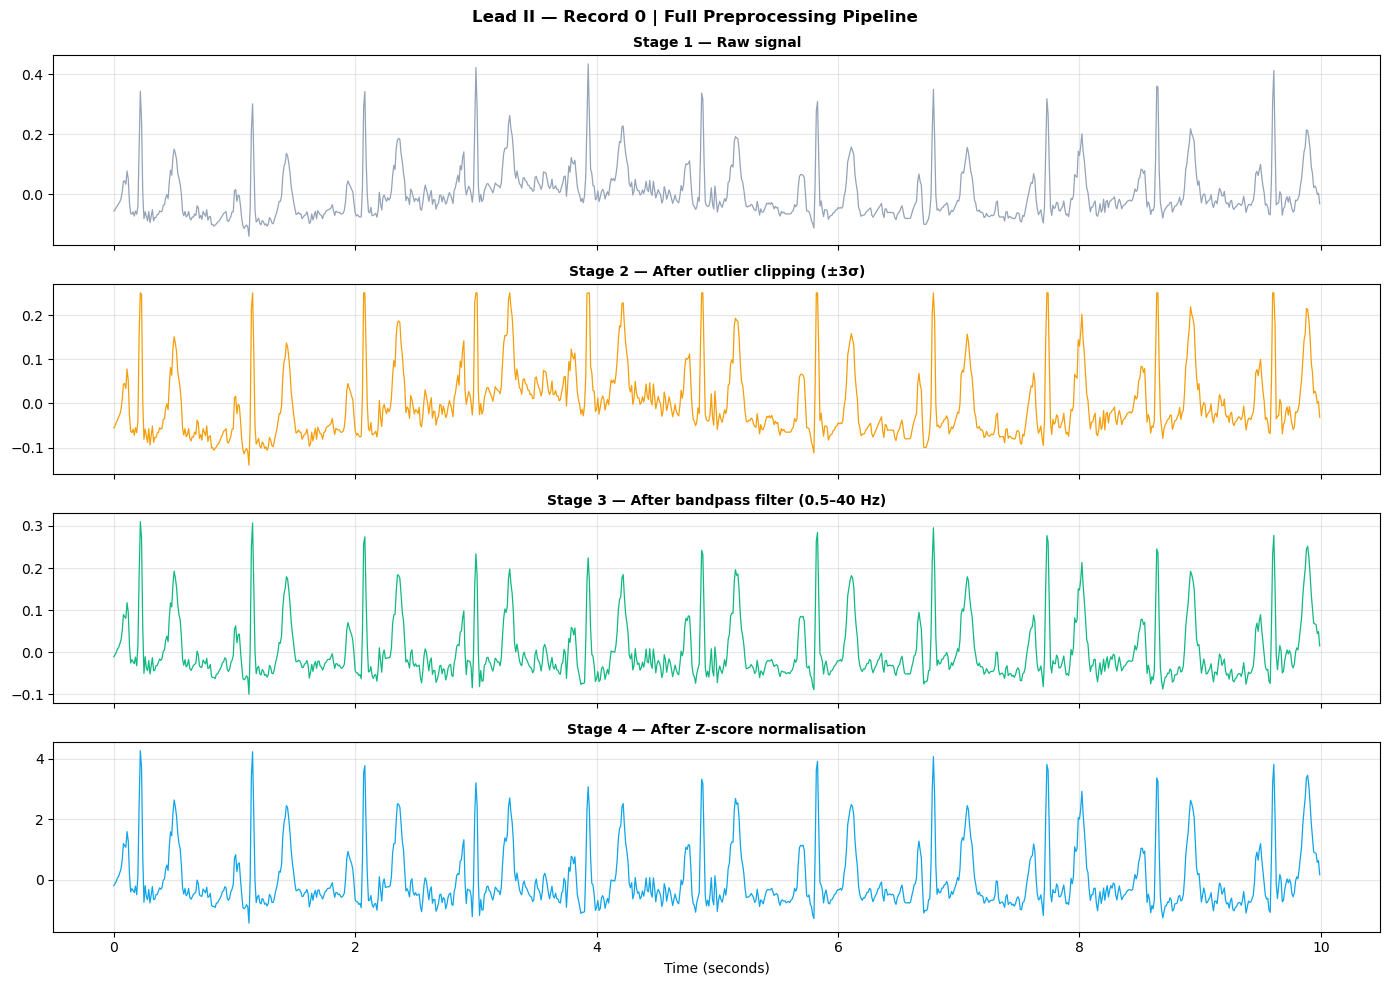

✅ Figure saved → reports/figures/preprocessing_pipeline.png


In [21]:
# ============================================================
# CELL 8: VISUALISE FULL PREPROCESSING PIPELINE (Lead II)
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
t        = np.arange(X_raw.shape[1]) / FS
lead_idx = 1   # Lead II

data_stages = [
    (X_raw[0, :, lead_idx],      '#94a3b8', 'Stage 1 — Raw signal'),
    (X_clipped[0, :, lead_idx],  '#f59e0b', 'Stage 2 — After outlier clipping (±3σ)'),
    (X_filtered[0, :, lead_idx], '#10b981', 'Stage 3 — After bandpass filter (0.5–40 Hz)'),
    (X_norm[0, :, lead_idx],     '#0ea5e9', 'Stage 4 — After Z-score normalisation'),
]

for ax, (signal, color, title) in zip(axes, data_stages):
    ax.plot(t, signal, color=color, linewidth=0.9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
fig.suptitle('Lead II — Record 0 | Full Preprocessing Pipeline', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'preprocessing_pipeline.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved → reports/figures/preprocessing_pipeline.png")

### Step 7 — Forecasting Window Construction ← CHANGED

**This replaces the old classification-style segmentation.**

Instead of pairing each window with a class label, we create **(input, target)** pairs
where the target is the **actual next 100 signal samples** — a regression target in mV.

```
Record (1000, 12):
  Window 0:  X_in = samples [0   : 500]   y_fore = samples [500 : 600]
  Window 1:  X_in = samples [100 : 600]   y_fore = samples [600 : 700]
  Window 2:  X_in = samples [200 : 700]   y_fore = samples [700 : 800]
  ...
```

No class labels. No multi-hot vectors. Pure signal → signal forecasting.

In [22]:
# ============================================================
# CELL 9: FORECASTING WINDOW CONSTRUCTION  ← CHANGED
#
# INPUT_LEN = 500  (5s) — encoder sees this
# HORIZON   = 100  (1s) — model must predict this
# STRIDE    = 100  (1s) — shift between windows
#
# Each record yields:  (1000 - 500 - 100) / 100 + 1 = 4 windows
# ============================================================

def build_forecast_windows(X, input_len, horizon, stride):
    """
    Build (input, target) forecasting pairs from signal records.

    Parameters
    ----------
    X         : (N_records, n_samples, n_leads)
    input_len : encoder input length in samples
    horizon   : forecast horizon in samples
    stride    : step between consecutive windows

    Returns
    -------
    X_in    : (N_windows, input_len, n_leads)  — past signal  (encoder input)
    y_fore  : (N_windows, horizon,   n_leads)  — future signal (regression target)
    rec_idx : (N_windows,)                     — source record index per window
    """
    n_records, n_samples, n_leads = X.shape
    total_len = input_len + horizon
    X_in_list, y_list, ridx_list = [], [], []

    for r in range(n_records):
        start = 0
        while start + total_len <= n_samples:
            X_in_list.append(X[r, start            : start + input_len, :])
            y_list.append(   X[r, start + input_len: start + total_len, :])
            ridx_list.append(r)
            start += stride

    return (
        np.array(X_in_list,  dtype=np.float32),
        np.array(y_list,     dtype=np.float32),
        np.array(ridx_list,  dtype=np.int32),
    )

X_in, y_fore, rec_idx = build_forecast_windows(X_norm, INPUT_LEN, HORIZON, STRIDE)

windows_per_rec = (X_norm.shape[1] - INPUT_LEN - HORIZON) // STRIDE + 1

print("=" * 60)
print("  FORECASTING WINDOW CONSTRUCTION")
print("=" * 60)
print(f"  INPUT_LEN          : {INPUT_LEN} samples  ({INPUT_LEN/FS:.0f} s)")
print(f"  HORIZON            : {HORIZON} samples  ({HORIZON/FS:.0f} s)")
print(f"  STRIDE             : {STRIDE} samples  ({STRIDE/FS:.0f} s)")
print(f"  Windows per record : {windows_per_rec}")
print(f"  Total records      : {len(X_norm)}")
print(f"  Total windows      : {len(X_in):,}")
print()
print(f"  X_in   shape : {X_in.shape}   ← encoder input  (past 5s)")
print(f"  y_fore shape : {y_fore.shape}   ← regression target (next 1s)")
print(f"  rec_idx shape: {rec_idx.shape}")
print()
print(f"  X_in   value range : [{X_in.min():.3f}, {X_in.max():.3f}]  mV (normalised)")
print(f"  y_fore value range : [{y_fore.min():.3f}, {y_fore.max():.3f}]  mV (normalised)")
print()
print("✅ Forecasting pairs constructed — targets are CONTINUOUS SIGNAL VALUES")
print("   (NOT class labels — this is regression, not classification)")

  FORECASTING WINDOW CONSTRUCTION
  INPUT_LEN          : 500 samples  (5 s)
  HORIZON            : 100 samples  (1 s)
  STRIDE             : 100 samples  (1 s)
  Windows per record : 5
  Total records      : 200
  Total windows      : 1,000

  X_in   shape : (1000, 500, 12)   ← encoder input  (past 5s)
  y_fore shape : (1000, 100, 12)   ← regression target (next 1s)
  rec_idx shape: (1000,)

  X_in   value range : [-8.056, 11.073]  mV (normalised)
  y_fore value range : [-8.344, 11.073]  mV (normalised)

✅ Forecasting pairs constructed — targets are CONTINUOUS SIGNAL VALUES
   (NOT class labels — this is regression, not classification)


### Step 8 — Forecasting Sanity Check ← CHANGED

Visualise one (input, target) forecasting pair to confirm the pipeline is correct.
The model must predict the **pink region** given only the **blue region**.

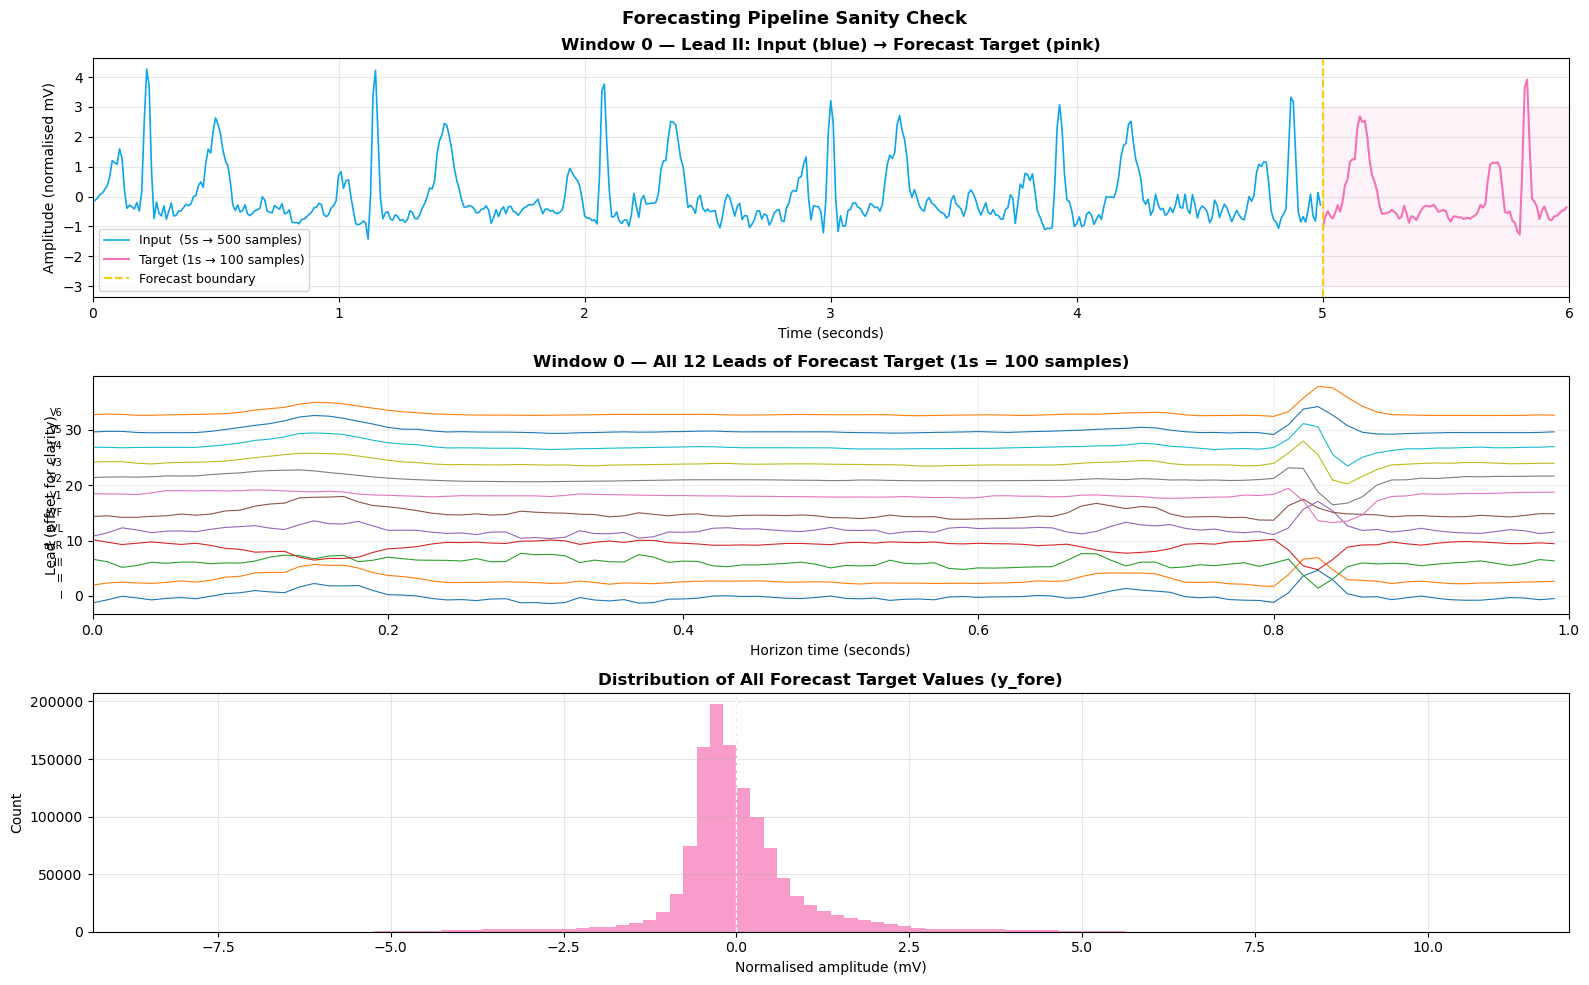

✅ Sanity check complete — input/target boundary looks correct
   Figure saved → reports/figures/forecasting_sanity_check.png


In [23]:
# ============================================================
# CELL 10: FORECASTING SANITY CHECK VISUALISATION  ← CHANGED
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

# ── Plot 1: input + target on continuous timeline ─────────────
ax = axes[0]
t_in  = np.arange(INPUT_LEN) / FS
t_all = np.arange(INPUT_LEN + HORIZON) / FS

# Reconstruct the full 6-second segment for window 0
full = np.concatenate([X_in[0, :, 1], y_fore[0, :, 1]])  # Lead II
ax.plot(t_in,  X_in[0,  :, 1], color='#0ea5e9', lw=1.2, label=f'Input  (5s → {INPUT_LEN} samples)')
ax.plot(np.arange(INPUT_LEN, INPUT_LEN + HORIZON) / FS,
        y_fore[0, :, 1], color='#f472b6', lw=1.5, label=f'Target (1s → {HORIZON} samples)')
ax.axvline(INPUT_LEN / FS, color='#facc15', ls='--', lw=1.5, label='Forecast boundary')
ax.fill_betweenx([-3, 3], INPUT_LEN/FS, (INPUT_LEN+HORIZON)/FS,
                 alpha=0.08, color='#f472b6')
ax.set_title('Window 0 — Lead II: Input (blue) → Forecast Target (pink)', fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude (normalised mV)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, (INPUT_LEN + HORIZON) / FS])

# ── Plot 2: all 12 leads of target window side by side ────────
ax2 = axes[1]
t_h = np.arange(HORIZON) / FS
for i, name in enumerate(LEAD_NAMES):
    ax2.plot(t_h, y_fore[0, :, i] + i * 3, lw=0.8)
    ax2.text(-0.02, i * 3, name, ha='right', va='center', fontsize=7)
ax2.set_title(f'Window 0 — All 12 Leads of Forecast Target ({HORIZON/FS:.0f}s = {HORIZON} samples)', fontweight='bold')
ax2.set_xlabel('Horizon time (seconds)')
ax2.set_ylabel('Lead (offset for clarity)')
ax2.grid(True, alpha=0.2)
ax2.set_xlim([0, HORIZON/FS])

# ── Plot 3: distribution of target values ────────────────────
ax3 = axes[2]
ax3.hist(y_fore.flatten(), bins=100, color='#f472b6', alpha=0.7, edgecolor='none')
ax3.set_title('Distribution of All Forecast Target Values (y_fore)', fontweight='bold')
ax3.set_xlabel('Normalised amplitude (mV)')
ax3.set_ylabel('Count')
ax3.grid(True, alpha=0.3)
ax3.axvline(0, color='white', ls='--', lw=1)

plt.suptitle('Forecasting Pipeline Sanity Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'forecasting_sanity_check.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sanity check complete — input/target boundary looks correct")
print(f"   Figure saved → reports/figures/forecasting_sanity_check.png")

### Step 9 — Patient-Wise Train / Val / Test Split

In [24]:
# ============================================================
# CELL 11: PATIENT-WISE TRAIN / VAL / TEST SPLIT
#
# Map each window back to its source record's strat_fold.
# PTB-XL guarantees no patient appears in more than one fold.
# Folds 1-8 = Train, 9 = Val, 10 = Test.
# ============================================================

record_folds = batch_df['strat_fold'].values        # (N_records,)
window_folds = record_folds[rec_idx]               # (N_windows,) — fold per window

train_mask = window_folds <= 8
val_mask   = window_folds == 9
test_mask  = window_folds == 10

X_train, y_train = X_in[train_mask],  y_fore[train_mask]
X_val,   y_val   = X_in[val_mask],    y_fore[val_mask]
X_test,  y_test  = X_in[test_mask],   y_fore[test_mask]

total = len(X_in)
print("=" * 60)
print("  PATIENT-WISE SPLIT")
print("=" * 60)
print(f"  Total windows    : {total:,}")
print(f"  Train  (f 1-8)   : {len(X_train):,}   ({100*len(X_train)/total:.1f}%)")
print(f"  Val    (f 9)     : {len(X_val):,}    ({100*len(X_val)/total:.1f}%)")
print(f"  Test   (f 10)    : {len(X_test):,}    ({100*len(X_test)/total:.1f}%)")
print()
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print()
print("  ✅ Zero data leakage — patient-safe split via PTB-XL strat_fold")

  PATIENT-WISE SPLIT
  Total windows    : 1,000
  Train  (f 1-8)   : 635   (63.5%)
  Val    (f 9)     : 210    (21.0%)
  Test   (f 10)    : 155    (15.5%)

  X_train : (635, 500, 12)   y_train : (635, 100, 12)
  X_val   : (210, 500, 12)    y_val   : (210, 100, 12)
  X_test  : (155, 500, 12)    y_test  : (155, 100, 12)

  ✅ Zero data leakage — patient-safe split via PTB-XL strat_fold


### Step 10 — Training-Time Data Augmentation

Applied **only to X_train (input windows)** — never to y_train (forecast targets).
Augmenting the target would corrupt the ground truth signal we are trying to predict.

Augmentation applied to training INPUT windows only:
  X_train_aug : (635, 500, 12)  (augmented inputs)
  y_train_aug : (635, 100, 12)  (targets — UNCHANGED)

  Strategies:
    ✅ Amplitude scaling   — gain ∈ [0.9, 1.1]
    ✅ Gaussian noise      — σ = 0.02
    ✅ Temporal shifting   — roll ∈ [−30, +30] samples (input only)
    ✅ Lead dropout        — prob=0.10


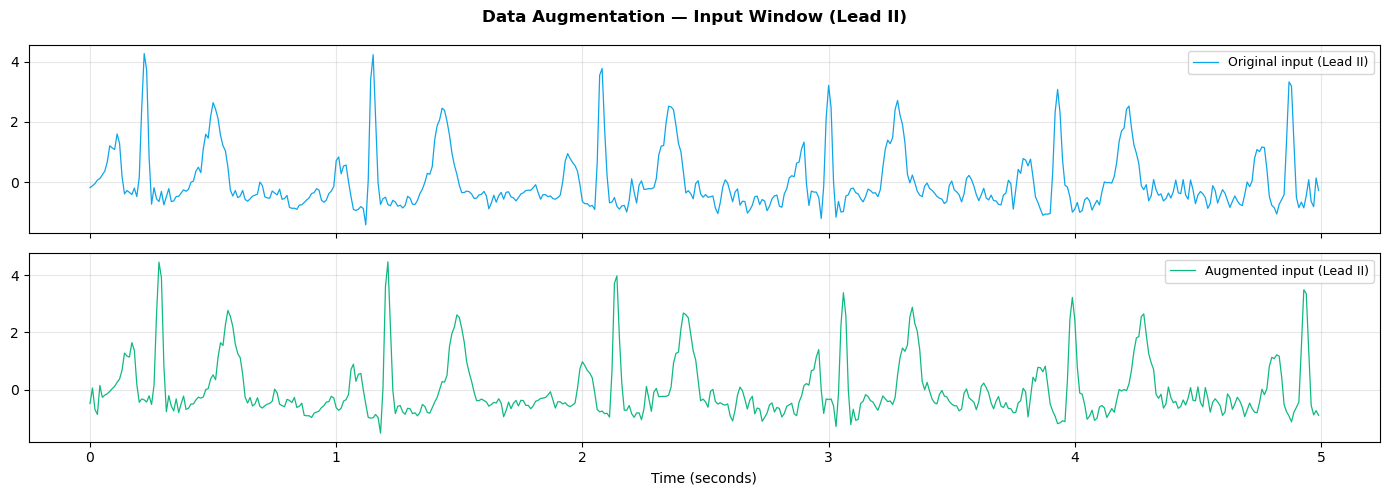

In [25]:
# ============================================================
# CELL 12: TRAINING-TIME DATA AUGMENTATION
#
# Applied ONLY to X_train (encoder input).
# y_train (forecast targets) are NEVER augmented —
# they are ground truth signal values that must stay pristine.
# ============================================================

RNG = np.random.default_rng(seed=42)

def augment_inputs(X_batch, rng, noise_std=0.02, shift_max=30, drop_prob=0.1):
    """
    Augment encoder input windows only.
    X_batch: (N, INPUT_LEN, 12)
    Returns: augmented X_batch, same shape.
    """
    X_aug = X_batch.copy()
    N     = len(X_aug)

    # 1. Amplitude scaling  gain ∈ [0.9, 1.1]
    X_aug *= rng.uniform(0.9, 1.1, size=(N, 1, 1))

    # 2. Additive Gaussian noise  σ = 0.02
    X_aug += rng.normal(0, noise_std, size=X_aug.shape)

    # 3. Temporal shift (only input — does NOT shift target boundary)
    shifts = rng.integers(-shift_max, shift_max + 1, size=N)
    for i, s in enumerate(shifts):
        if s != 0:
            X_aug[i] = np.roll(X_aug[i], s, axis=0)

    # 4. Lead dropout — zero out one random lead with prob 0.10
    for i in range(N):
        if rng.random() < drop_prob:
            X_aug[i, :, rng.integers(0, 12)] = 0.0

    return X_aug

X_train_aug = augment_inputs(X_train, RNG)
y_train_aug = y_train.copy()   # ← targets UNCHANGED — ground truth preserved

print("Augmentation applied to training INPUT windows only:")
print(f"  X_train_aug : {X_train_aug.shape}  (augmented inputs)")
print(f"  y_train_aug : {y_train_aug.shape}  (targets — UNCHANGED)")
print()
print("  Strategies:")
print("    ✅ Amplitude scaling   — gain ∈ [0.9, 1.1]")
print("    ✅ Gaussian noise      — σ = 0.02")
print("    ✅ Temporal shifting   — roll ∈ [−30, +30] samples (input only)")
print("    ✅ Lead dropout        — prob=0.10")

# Quick visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
t = np.arange(INPUT_LEN) / FS
axes[0].plot(t, X_train[0, :, 1],     color='#0ea5e9', lw=0.9, label='Original input (Lead II)')
axes[1].plot(t, X_train_aug[0, :, 1], color='#10b981', lw=0.9, label='Augmented input (Lead II)')
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Data Augmentation — Input Window (Lead II)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'augmentation_example.png'), dpi=150, bbox_inches='tight')
plt.show()

### Step 11 — Full Preprocessing Sanity Check ← NEW

A comprehensive automated check that verifies every critical property of the
preprocessed data before saving. If anything fails, the pipeline should not proceed.

In [26]:
# ============================================================
# CELL 13: FULL SANITY CHECK  ← NEW
#
# Runs automated assertions on every output array.
# A clean run means the data is ready for modelling.
# ============================================================

print("=" * 60)
print("  FULL PREPROCESSING SANITY CHECK")
print("=" * 60)

errors   = []
warnings_ = []

def check(condition, label, error=True):
    symbol = "✅" if condition else ("❌" if error else "⚠️")
    print(f"  {symbol}  {label}")
    if not condition:
        (errors if error else warnings_).append(label)

# ── Shape checks ──────────────────────────────────────────────
check(X_train_aug.ndim == 3,        "X_train is 3-D (N, INPUT_LEN, 12)")
check(y_train_aug.ndim == 3,        "y_train is 3-D (N, HORIZON, 12)  ← regression target")
check(X_train_aug.shape[1] == INPUT_LEN, f"X_train input length = {INPUT_LEN}")
check(y_train_aug.shape[1] == HORIZON,   f"y_train horizon = {HORIZON}")
check(X_train_aug.shape[2] == 12,   "X_train has 12 leads")
check(y_train_aug.shape[2] == 12,   "y_train has 12 leads")
check(X_train_aug.shape[0] == y_train_aug.shape[0], "X_train and y_train same N")
check(X_val.shape[0]  == y_val.shape[0],  "X_val and y_val same N")
check(X_test.shape[0] == y_test.shape[0], "X_test and y_test same N")

print()

# ── dtype checks ─────────────────────────────────────────────
check(X_train_aug.dtype == np.float32, "X_train dtype is float32")
check(y_train_aug.dtype == np.float32, "y_train dtype is float32  (continuous mV, NOT int labels)")

print()

# ── Value range checks (after normalisation, ~[-4, 4]) ────────
for name, arr in [('X_train', X_train_aug), ('y_train', y_train_aug),
                   ('X_val',   X_val),        ('y_val',   y_val),
                   ('X_test',  X_test),        ('y_test',  y_test)]:
    in_range = (arr.min() > -10) and (arr.max() < 10)
    check(in_range, f"{name} values in plausible normalised range [{arr.min():.2f}, {arr.max():.2f}]")

print()

# ── Leakage check: no patient appears in multiple splits ──────
train_recs = set(rec_idx[train_mask].tolist())
val_recs   = set(rec_idx[val_mask].tolist())
test_recs  = set(rec_idx[test_mask].tolist())
check(len(train_recs & val_recs)  == 0, "No record overlap: train ∩ val  = ∅")
check(len(train_recs & test_recs) == 0, "No record overlap: train ∩ test = ∅")
check(len(val_recs   & test_recs) == 0, "No record overlap: val   ∩ test = ∅")

print()

# ── NaN / Inf checks ─────────────────────────────────────────
for name, arr in [('X_train', X_train_aug), ('y_train', y_train_aug),
                   ('X_val', X_val), ('y_val', y_val),
                   ('X_test', X_test), ('y_test', y_test)]:
    check(not np.isnan(arr).any(), f"No NaN in {name}")
    check(not np.isinf(arr).any(), f"No Inf in {name}")

print()

# ── Forecasting-specific: y_fore is continuous, NOT binary ────
unique_vals = np.unique(y_train_aug[:10].round(3))
check(len(unique_vals) > 10,
      f"y_train contains continuous values (not binary labels) — {len(unique_vals)} unique in sample")

print()
print("=" * 60)
if errors:
    print(f"  ❌ {len(errors)} ERRORS — fix before proceeding:")
    for e in errors:
        print(f"     • {e}")
else:
    print("  ✅ ALL CHECKS PASSED — data is ready for modelling")
print("=" * 60)

print(f"\n  Final split summary:")
print(f"    Train : X={X_train_aug.shape}  y={y_train_aug.shape}")
print(f"    Val   : X={X_val.shape}   y={y_val.shape}")
print(f"    Test  : X={X_test.shape}   y={y_test.shape}")

  FULL PREPROCESSING SANITY CHECK
  ✅  X_train is 3-D (N, INPUT_LEN, 12)
  ✅  y_train is 3-D (N, HORIZON, 12)  ← regression target
  ✅  X_train input length = 500
  ✅  y_train horizon = 100
  ✅  X_train has 12 leads
  ✅  y_train has 12 leads
  ✅  X_train and y_train same N
  ✅  X_val and y_val same N
  ✅  X_test and y_test same N

  ✅  X_train dtype is float32
  ✅  y_train dtype is float32  (continuous mV, NOT int labels)

  ❌  X_train values in plausible normalised range [-8.10, 10.50]
  ❌  y_train values in plausible normalised range [-8.34, 11.07]
  ✅  X_val values in plausible normalised range [-7.46, 9.47]
  ✅  y_val values in plausible normalised range [-7.22, 9.47]
  ✅  X_test values in plausible normalised range [-7.07, 8.97]
  ✅  y_test values in plausible normalised range [-6.92, 8.97]

  ✅  No record overlap: train ∩ val  = ∅
  ✅  No record overlap: train ∩ test = ∅
  ✅  No record overlap: val   ∩ test = ∅

  ✅  No NaN in X_train
  ✅  No Inf in X_train
  ✅  No NaN in y_train

### Step 12 — Save All Outputs

In [27]:
# ============================================================
# CELL 14: SAVE ALL PROCESSED OUTPUTS → data/processed/
# ============================================================

os.makedirs(SAVE_DIR, exist_ok=True)

# Full clean record array (pre-windowing) — used by EDA notebook
np.save(os.path.join(SAVE_DIR, 'X_clean.npy'), X_norm)

# Forecasting splits — used by 04_modeling.ipynb
np.save(os.path.join(SAVE_DIR, 'X_train.npy'), X_train_aug)   # (N, 500, 12) inputs
np.save(os.path.join(SAVE_DIR, 'y_train.npy'), y_train_aug)   # (N, 100, 12) targets ← signal, not labels

np.save(os.path.join(SAVE_DIR, 'X_val.npy'),   X_val)
np.save(os.path.join(SAVE_DIR, 'y_val.npy'),   y_val)

np.save(os.path.join(SAVE_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(SAVE_DIR, 'y_test.npy'),  y_test)

# Config
config = {
    'sampling_rate'        : FS,
    'input_len'            : INPUT_LEN,
    'horizon'              : HORIZON,
    'stride'               : STRIDE,
    'lead_names'           : LEAD_NAMES,
    'n_leads'              : 12,
    'task'                 : 'forecasting',  # ← explicit
    'target_type'          : 'continuous_signal_mV',
    'windows_per_record'   : windows_per_rec,
}
with open(os.path.join(SAVE_DIR, 'config.pkl'), 'wb') as f:
    pickle.dump(config, f)

print("=" * 60)
print("  SAVED → data/processed/")
print("=" * 60)
files = {
    'X_clean.npy' : X_norm.shape,
    'X_train.npy' : X_train_aug.shape,
    'y_train.npy' : y_train_aug.shape,   # ← continuous signal
    'X_val.npy'   : X_val.shape,
    'y_val.npy'   : y_val.shape,
    'X_test.npy'  : X_test.shape,
    'y_test.npy'  : y_test.shape,
}
for fname, shape in files.items():
    print(f"  {fname:<18} → {shape}")

print()
print(f"  config.pkl  → task='{config['task']}'  target='{config['target_type']}'")
print()
print("✅ 02_preprocessing complete!")
print("   Next → 03_eda.ipynb  or  04_modeling.ipynb")

  SAVED → data/processed/
  X_clean.npy        → (200, 1000, 12)
  X_train.npy        → (635, 500, 12)
  y_train.npy        → (635, 100, 12)
  X_val.npy          → (210, 500, 12)
  y_val.npy          → (210, 100, 12)
  X_test.npy         → (155, 500, 12)
  y_test.npy         → (155, 100, 12)

  config.pkl  → task='forecasting'  target='continuous_signal_mV'

✅ 02_preprocessing complete!
   Next → 03_eda.ipynb  or  04_modeling.ipynb
